In [21]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [22]:
from langchain_groq import ChatGroq

os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.1', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000028FAD5FFB60>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000028FAD5FF830>, model_name='openai/gpt-oss-120b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [23]:
import arxiv
from langchain_core.tools import tool

@tool
def arxiv_tool(query: str, max_results: int = 5, sort_by: str = "relevance", category: str = None) -> list:
    """
    Search arXiv and return structured metadata for the top matching papers.
    sort_by: 'relevance' or 'recent'
    category: optional arXiv category code (e.g. 'cs.CL') to restrict results
    """
    client = arxiv.Client(
        page_size=max_results,
        delay_seconds=3,
        num_retries=5,
    )

    sort_criterion = (
        arxiv.SortCriterion.SubmittedDate if sort_by == "recent"
        else arxiv.SortCriterion.Relevance
    )

    # Build query string with category constraint if provided
    if category:
        full_query = f"cat:{category} AND all:{query}"
    else:
        full_query = f"all:{query}"

    search = arxiv.Search(
        query=full_query,
        max_results=max_results,
        sort_by=sort_criterion,
    )

    papers = []
    try:
        for paper in client.results(search):
            papers.append({
                "title": paper.title.strip(),
                "authors": ", ".join(a.name for a in paper.authors),
                "published": paper.published.date().isoformat(),
                "summary": paper.summary.strip(),
                "link": paper.entry_id,
                "arxiv_id": paper.get_short_id(),
                "pdf_url": paper.pdf_url,
            })
    except Exception as e:
        return [{"error": str(e)}]

    return papers

In [24]:
def get_text_content(response) -> str:
    """
    Handles both plain string responses and list-of-content-blocks responses
    (some models/providers return content as a list of blocks instead of a plain string).
    """
    content = response.content

    if isinstance(content, str):
        return content

    if isinstance(content, list):
        text_parts = []
        for block in content:
            if isinstance(block, dict):
                if block.get("type") == "text":
                    text_parts.append(block.get("text", ""))
            elif isinstance(block, str):
                text_parts.append(block)
        return "".join(text_parts)

    return str(content)

In [25]:
import json
from langchain_core.messages import HumanMessage

def interpret_query_node(state: dict) -> dict:
    prompt = f"""Convert this user request into a clean arXiv search query and parameters.

If the query contains a term that could be ambiguous across different fields
(e.g., "transformers" could mean ML/AI architecture or electrical hardware,
"attention" could mean the ML mechanism or a general English word),
add clarifying keywords to disambiguate. If no other context is given in the
request, default to the machine learning / AI research interpretation, since
this tool is part of an AI/ML research assistant.

Also identify the most relevant arXiv category code, if clearly identifiable:
- cs.CL = Computation and Language (NLP)
- cs.LG = Machine Learning
- cs.AI = Artificial Intelligence
- cs.CV = Computer Vision
- cs.NE = Neural and Evolutionary Computing
- cs.SD = Sound (speech/audio)
Use null if no category is clearly appropriate.

User request: "{state['raw_query']}"

Reply only in this JSON format, no other text:
{{
    "search_terms": "<concise, disambiguated keyword-based search string>",
    "category": "<category code like 'cs.CL', or null>",
    "sort_by": "<'relevance' or 'recent'>",
    "max_results": <integer, default 5>
}}"""

    response = llm.invoke([HumanMessage(content=prompt)])
    raw_text = get_text_content(response)
    parsed = json.loads(raw_text)

    state["search_terms"] = parsed["search_terms"]
    state["category"] = parsed.get("category")
    state["sort_by"] = parsed.get("sort_by", "relevance")
    if state.get("max_results") is None:
        state["max_results"] = parsed.get("max_results", 5)
    return state

In [26]:
def call_arxiv_node(state: dict) -> dict:
    # Fetch more than the user's requested count, to give filtering something to work with
    fetch_count = max(state["max_results"] * 2, 10)
    results = arxiv_tool.invoke({
        "query": state["search_terms"],
        "max_results": fetch_count,
        "sort_by": state["sort_by"],
        "category": state.get("category"),
    })
    state["raw_results"] = results
    return state

In [27]:
def filter_relevance_node(state: dict) -> dict:
    results = state["raw_results"]
    if not results or "error" in results[0]:
        return state

    titles_summary = "\n".join(
        f"[{i}] {r['title']}: {r['summary'][:400]}" for i, r in enumerate(results)
    )

    prompt = f"""Original search intent: "{state['raw_query']}"

Candidate papers:
{titles_summary}

For EACH paper, determine if it is relevant. A paper is RELEVANT only if it is
fundamentally ABOUT the transformer/attention architecture itself (its design,
theory, training, or core mechanics) as a machine learning topic.

A paper is NOT relevant if it merely APPLIES a model that happens to be named
"Transformer" to a different domain (e.g. finance, trading, weather, medical
diagnosis) without the paper's core contribution being about the architecture
itself. Example: "Momentum Transformer for Trading" is NOT relevant — it's a
finance paper that uses a transformer as a tool, not a paper about transformers.

Reply ONLY in this JSON format, no other text:
{{
    "evaluations": [
        {{"index": 0, "relevant": true, "reason": "..."}}
    ],
    "keep_indices": [0, 2, 4]
}}
Include at most {state['max_results']} indices in keep_indices."""

    response = llm.invoke([HumanMessage(content=prompt)])
    raw_text = get_text_content(response)
    parsed = json.loads(raw_text)
    print(parsed.get("evaluations", []))

    # Extract keep_indices, defensively handling type/shape variations
    if isinstance(parsed, dict):
        keep_indices = parsed.get("keep_indices", [])
    else:
        keep_indices = parsed

    keep_indices = [int(i) for i in keep_indices]

    state["raw_results"] = [results[i] for i in keep_indices if i < len(results)]
    return state

In [28]:
def generate_alternate_query(original_query: str, previous_terms: list) -> str:
    prompt = f"""The search terms "{previous_terms[-1]}" for the topic "{original_query}"
did not return enough genuinely relevant papers on arXiv.

Suggest a DIFFERENT search phrasing that explores the SAME core topic from another angle.
The new phrasing MUST still center on the original subject matter — do not drift into
a broader or unrelated domain. Only vary terminology, framing, or related subfields
that stay tightly connected to: "{original_query}"

Avoid repeating these already-tried terms: {previous_terms}

Reply ONLY with the new search string, no other text."""

    response = llm.invoke([HumanMessage(content=prompt)])
    return get_text_content(response).strip()

In [29]:
MAX_RETRY_ROUNDS = 1  # reduced from 2, per the latency fix — caps at 2 total search rounds

In [30]:
def call_and_filter_with_retry(state: dict) -> dict:
    requested = state["max_results"]
    all_kept = []
    seen_arxiv_ids = set()
    tried_terms = [state["search_terms"]]

    for round_num in range(MAX_RETRY_ROUNDS + 1):
        current_terms = tried_terms[-1]
        fetch_state = {**state, "search_terms": current_terms, "max_results": max(requested * 2, 10)}

        fetch_state = call_arxiv_node(fetch_state)
        fetch_state = filter_relevance_node(fetch_state)

        new_finds = [r for r in fetch_state["raw_results"] if r["arxiv_id"] not in seen_arxiv_ids]
        for r in new_finds:
            all_kept.append(r)
            seen_arxiv_ids.add(r["arxiv_id"])

        if len(all_kept) >= requested or round_num == MAX_RETRY_ROUNDS:
            break

        # If this round found literally nothing new, one more differently-angled try is
        # still worth it once, but don't keep hammering if we already retried
        new_terms = generate_alternate_query(state["raw_query"], tried_terms)
        tried_terms.append(new_terms)

    state["raw_results"] = all_kept[:requested]
    state["search_terms_tried"] = tried_terms
    return state

In [31]:
def format_results_node(state: dict) -> dict:
    results = state["raw_results"]
    requested = state["max_results"]

    if not results:
        state["formatted_output"] = []
        state["result_note"] = "No papers found that are specifically relevant to this topic. Try broadening your search terms."
    elif len(results) < requested:
        state["formatted_output"] = results
        state["result_note"] = (
            f"Found {len(results)} genuinely relevant paper(s) out of {requested} requested — "
            f"this topic may be narrow, or arXiv's coverage may be limited."
        )
    else:
        state["formatted_output"] = results
        state["result_note"] = None

    return state

In [32]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, List, Optional

class DiscoverState(TypedDict):
    raw_query: str
    search_terms: str
    category: Optional[str]
    sort_by: str
    max_results: int
    raw_results: list
    search_terms_tried: list
    formatted_output: list
    result_note: Optional[str]

In [33]:
graph = StateGraph(DiscoverState)

graph.add_node("interpret_query", interpret_query_node)
graph.add_node("search_and_filter", call_and_filter_with_retry)  # replaces call_arxiv + filter_relevance as separate nodes
graph.add_node("format_results", format_results_node)

graph.set_entry_point("interpret_query")
graph.add_edge("interpret_query", "search_and_filter")
graph.add_edge("search_and_filter", "format_results")
graph.add_edge("format_results", END)

discover_graph = graph.compile()

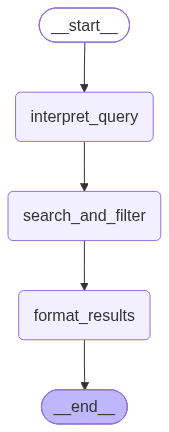

In [34]:
from IPython.display import display, Image

Image(discover_graph.get_graph().draw_mermaid_png())

In [35]:
def discover_papers(user_query: str, max_results: int = None) -> dict:
    initial_state: DiscoverState = {
        "raw_query": user_query,
        "search_terms": "",
        "category": None,
        "sort_by": "relevance",
        "max_results": max_results,
        "raw_results": [],
        "search_terms_tried": [],
        "formatted_output": [],
        "result_note": None,
    }

    result = discover_graph.invoke(initial_state)

    return {
        "results": result["formatted_output"],
        "result_note": result["result_note"],
        "search_terms_used": result["search_terms_tried"],
    }

In [36]:
response = discover_papers("reinforcement learning transformers", max_results=3)
print("Note:", response["result_note"])
print(f"Results: {len(response['results'])}")

[{'index': 0, 'relevant': False, 'reason': 'Focuses on value bonuses for exploration; no discussion of transformer or attention architectures.'}, {'index': 1, 'relevant': False, 'reason': 'Introduces a curriculum learning method based on causal models; does not address transformer design.'}, {'index': 2, 'relevant': False, 'reason': 'Applies a pre‑trained GPT‑style transformer to urban mobility trajectory generation; the contribution is an application, not transformer theory or design.'}, {'index': 3, 'relevant': False, 'reason': 'Presents Anderson acceleration for value iteration; unrelated to transformer architectures.'}, {'index': 4, 'relevant': False, 'reason': 'A tutorial on meta‑RL methods; no focus on transformers or attention mechanisms.'}, {'index': 5, 'relevant': False, 'reason': 'Stabilizes Extreme Q‑learning via Maclaurin expansion; does not involve transformers.'}, {'index': 6, 'relevant': False, 'reason': 'Describes a multi‑head RL framework but not a transformer/attentio